In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
SAU <- read.csv("SeaAroundUs//SAU EEZ 862 v50-1//SAU EEZ 862 v50-1.csv")

In [3]:
str(SAU)

'data.frame':	50513 obs. of  17 variables:
 $ area_name        : chr  "Venezuela" "Venezuela" "Venezuela" "Venezuela" ...
 $ area_type        : chr  "eez" "eez" "eez" "eez" ...
 $ data_layer       : chr  "Reconstructed domestic catch" "Reconstructed domestic catch" "Reconstructed domestic catch" "Reconstructed domestic catch" ...
 $ uncertainty_score: int  1 1 1 1 1 1 1 1 1 1 ...
 $ year             : int  1950 1950 1950 1950 1950 1950 1950 1950 1950 1950 ...
 $ scientific_name  : chr  "Marine fishes not identified" "Marine fishes not identified" "Marine fishes not identified" "Marine fishes not identified" ...
 $ common_name      : chr  "Marine fishes nei" "Marine fishes nei" "Marine fishes nei" "Marine fishes nei" ...
 $ functional_group : chr  "Medium demersals (30 - 89 cm)" "Medium demersals (30 - 89 cm)" "Medium demersals (30 - 89 cm)" "Medium demersals (30 - 89 cm)" ...
 $ commercial_group : chr  "Other fishes & inverts" "Other fishes & inverts" "Other fishes & inverts" "Other fi

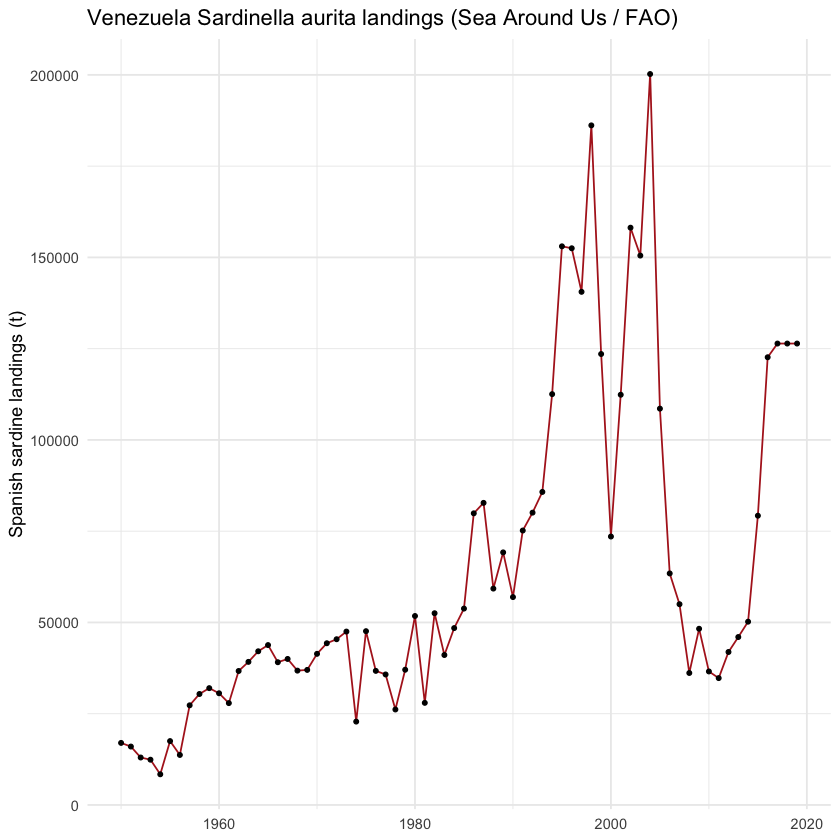

In [4]:
df_sardine_sau <- SAU %>%
  filter(scientific_name   == "Sardinella aurita",
         data_layer        == "Reconstructed domestic catch",
         catch_type        == "Landings",
         reporting_status  == "Reported") %>%       # straight FAO baseline
  group_by(year) %>%
  summarise(sardinelandings = sum(tonnes), .groups = "drop")

# overview plot
ggplot(df_sardine_sau, aes(year, sardinelandings)) +
  geom_line(colour = "firebrick") + geom_point(size = 1) +
  labs(x = NULL, y = "Spanish sardine landings (t)",
       title = "Venezuela Sardinella aurita landings (Sea Around Us / FAO)") +
  theme_minimal()

# save, matching your processed/ convention (new name so it won't clobber the digitized one)
saveRDS(df_sardine_sau, "processed/sardine_sau.rds")
write.csv(df_sardine_sau, "processed/sardine_sau.csv", row.names = FALSE)